In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import statistics as stats

df = pd.read_csv("../data/dirty_data.csv")
df.head(20)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [2]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


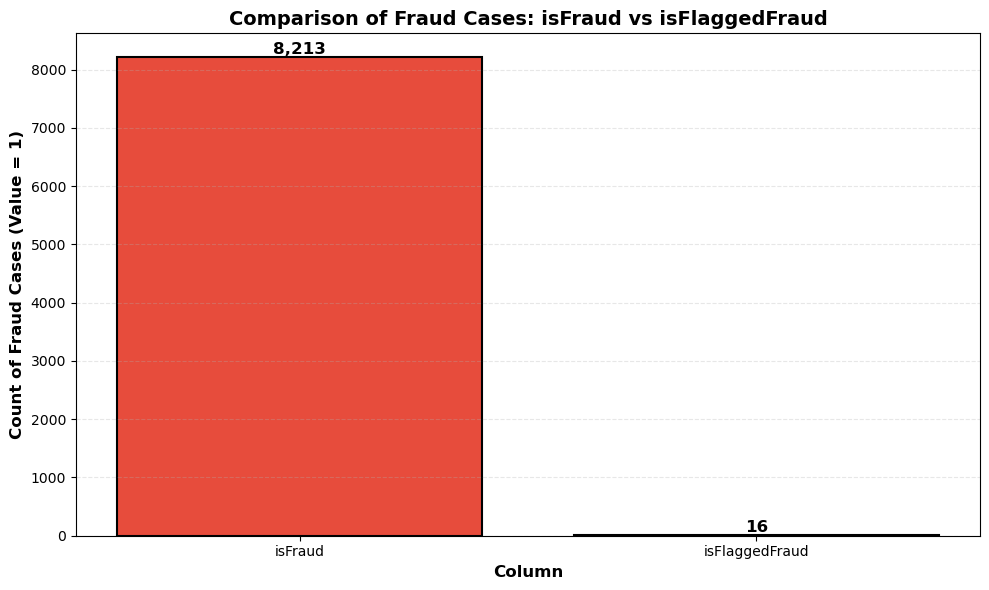

Count of 1s in isFraud: 8,213
Count of 1s in isFlaggedFraud: 16

Difference: 8,197
Detection rate: 0.19%


In [ ]:
# Count of 1 values in isFraud vs isFlaggedFraud
fraud_count = (df['isFraud'] == 1).sum()
flagged_count = (df['isFlaggedFraud'] == 1).sum()

# Create bar chart
plt.figure(figsize=(10, 6))
categories = ['isFraud', 'isFlaggedFraud']
counts = [fraud_count, flagged_count]
colors = ['#e74c3c', '#3498db']

bars = plt.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Column', fontsize=12, fontweight='bold')
plt.ylabel('Count of Fraud Cases (Value = 1)', fontsize=12, fontweight='bold')
plt.title('Comparison of Fraud Cases: isFraud vs isFlaggedFraud', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nDifference: {fraud_count - flagged_count:,}")
print(f"Detection rate: {(flagged_count / fraud_count * 100):.2f}%" if fraud_count > 0 else "N/A")

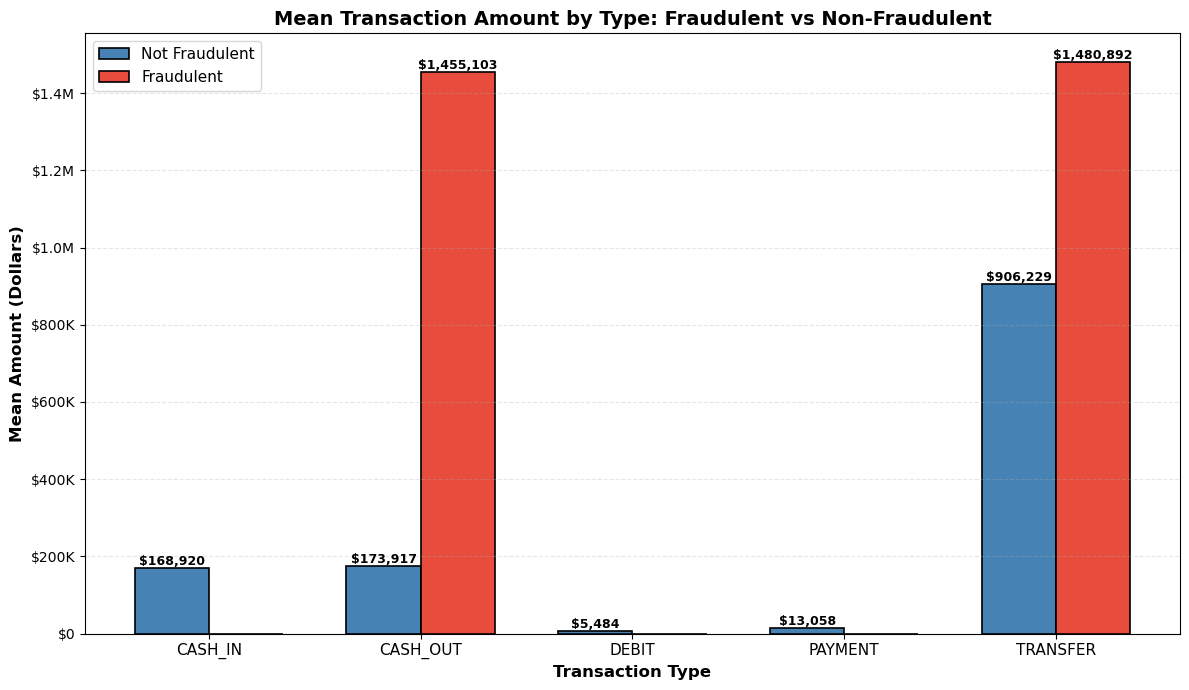



Transaction Count by Type

Type            Not Fraud            Fraud               
-------------------------------------------------------
CASH_IN               1,399,284                      0
CASH_OUT              2,233,384                  4,116
DEBIT                    41,432                      0
PAYMENT               2,151,495                      0
TRANSFER                528,812                  4,097


In [15]:
# Bar graph: Mean Amount by Transaction Type (Fraud vs Non-Fraud)
from matplotlib.ticker import FuncFormatter

# Function to format y-axis as dollars
def dollar_formatter(x, p):
    if x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'${x/1_000:.0f}K'
    else:
        return f'${x:.0f}'

# Calculate mean amount by type and fraud status
fraud_mean = df[df['isFraud'] == 1].groupby('type')['amount'].mean()
not_fraud_mean = df[df['isFraud'] == 0].groupby('type')['amount'].mean()

# Get all transaction types
all_types = sorted(df['type'].unique())

# Prepare data for plotting
fraud_values = [fraud_mean.get(t, 0) for t in all_types]
not_fraud_values = [not_fraud_mean.get(t, 0) for t in all_types]

# Create bar graph
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(all_types))
width = 0.35

bars1 = ax.bar(x - width/2, not_fraud_values, width, label='Not Fraudulent', 
               color='steelblue', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, fraud_values, width, label='Fraudulent', 
               color='#e74c3c', edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Transaction Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Amount (Dollars)', fontsize=12, fontweight='bold')
ax.set_title('Mean Transaction Amount by Type: Fraudulent vs Non-Fraudulent', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_types, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()



# Count of transactions by type and fraud status
print("\n\nTransaction Count by Type\n")
fraud_count = df[df['isFraud'] == 1].groupby('type').size()
not_fraud_count = df[df['isFraud'] == 0].groupby('type').size()

print(f"{'Type':<15} {'Not Fraud':<20} {'Fraud':<20}")
print("-" * 55)
for t in all_types:
    nf_count = not_fraud_count.get(t, 0)
    f_count = fraud_count.get(t, 0)
    print(f"{t:<15} {nf_count:>15,}        {f_count:>15,}")

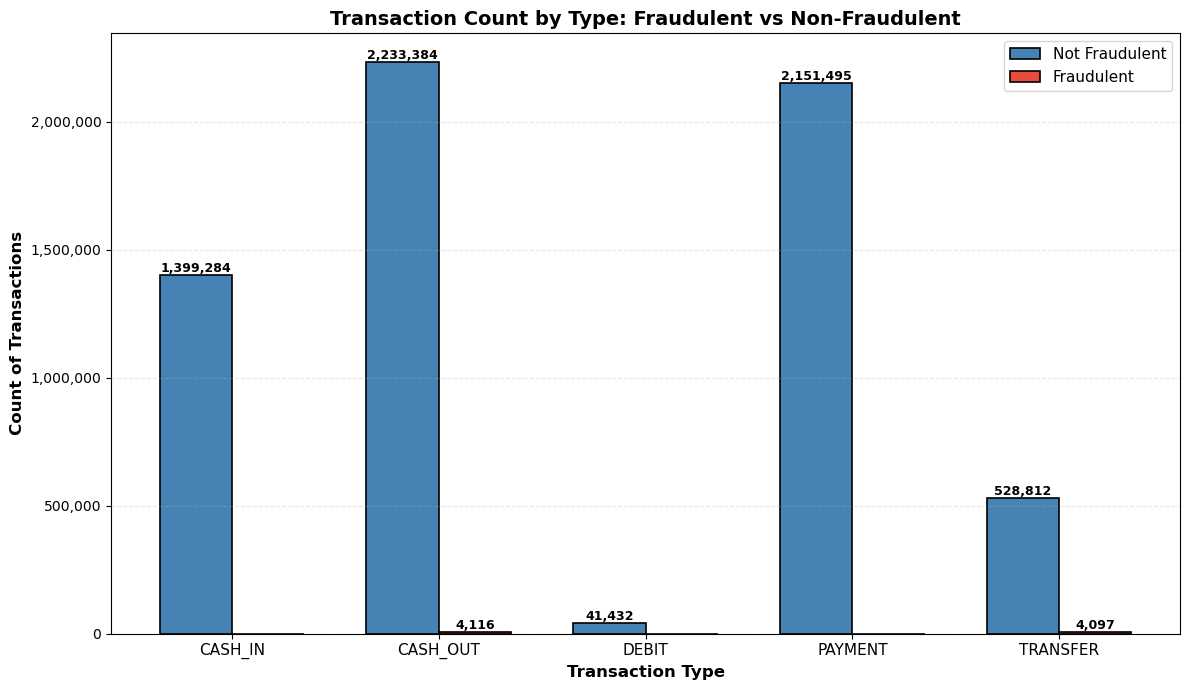


Overall Summary
Total Not Fraudulent: 6,354,407
Total Fraudulent: 8,213
Overall Fraud Rate: 0.1291%


In [16]:
# Bar graph: Count of Fraud vs Non-Fraud by Transaction Type

# Calculate count by type and fraud status
fraud_count = df[df['isFraud'] == 1].groupby('type').size()
not_fraud_count = df[df['isFraud'] == 0].groupby('type').size()

# Get all transaction types
all_types = sorted(df['type'].unique())

# Prepare data for plotting
fraud_values = [fraud_count.get(t, 0) for t in all_types]
not_fraud_values = [not_fraud_count.get(t, 0) for t in all_types]

# Create bar graph
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(all_types))
width = 0.35

bars1 = ax.bar(x - width/2, not_fraud_values, width, label='Not Fraudulent', 
               color='steelblue', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, fraud_values, width, label='Fraudulent', 
               color='#e74c3c', edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Transaction Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Count of Transactions', fontsize=12, fontweight='bold')
ax.set_title('Transaction Count by Type: Fraudulent vs Non-Fraudulent', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_types, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Format y-axis with commas for thousands
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()




# Overall summary
print("\nOverall Summary")
total_fraud = df['isFraud'].sum()
total_not_fraud = len(df) - total_fraud
print(f"Total Not Fraudulent: {total_not_fraud:,}")
print(f"Total Fraudulent: {total_fraud:,}")
print(f"Overall Fraud Rate: {(total_fraud / len(df) * 100):.4f}%")

In [ ]:
# Mean oldbalanceOrg amount of fraudulent instances

# Filter for fraudulent transactions only
fraudulent_transactions = df[df['isFraud'] == 1]

# Calculate mean oldbalanceOrg for fraudulent instances
mean_old_balance_fraud = fraudulent_transactions['oldbalanceOrg'].mean()

print("=== Mean oldbalanceOrg for Fraudulent Transactions ===\n")
print(f"Mean oldbalanceOrg (Fraud): ${mean_old_balance_fraud:,.2f}")

# Additional statistics for context
print("\n Additional Statistics for Fraudulent Transactions \n")
print(f"Median oldbalanceOrg (Fraud): ${fraudulent_transactions['oldbalanceOrg'].median():,.2f}")
print(f"Min oldbalanceOrg (Fraud): ${fraudulent_transactions['oldbalanceOrg'].min():,.2f}")
print(f"Max oldbalanceOrg (Fraud): ${fraudulent_transactions['oldbalanceOrg'].max():,.2f}")


# Compare with non-fraudulent
non_fraudulent_transactions = df[df['isFraud'] == 0]
mean_old_balance_not_fraud = non_fraudulent_transactions['oldbalanceOrg'].mean()

print("\n=== Comparison with Non-Fraudulent Transactions ===\n")
print(f"Mean oldbalanceOrg (Not Fraud): ${mean_old_balance_not_fraud:,.2f}")
print(f"Mean oldbalanceOrg (Fraud): ${mean_old_balance_fraud:,.2f}")


=== Mean oldbalanceOrg for Fraudulent Transactions ===

Mean oldbalanceOrg (Fraud): $1,649,667.61

=== Additional Statistics for Fraudulent Transactions ===

Median oldbalanceOrg (Fraud): $438,983.45
Min oldbalanceOrg (Fraud): $0.00
Max oldbalanceOrg (Fraud): $59,585,040.37
Std Dev oldbalanceOrg (Fraud): $3,547,719.44

Total Fraudulent Transactions: 8,213

=== Comparison with Non-Fraudulent Transactions ===

Mean oldbalanceOrg (Not Fraud): $832,828.71
Mean oldbalanceOrg (Fraud): $1,649,667.61

Difference: $816,838.89
Fraud mean is 1.98x the non-fraud mean


In [ ]:
# Count of 0.00 instances in oldbalanceOrg column

# Count zeros in oldbalanceOrg
zero_count = (df['oldbalanceOrg'] == 0.00).sum()
total_count = len(df)
zero_percentage = (zero_count / total_count) * 100

print("=== Count of 0.00 in oldbalanceOrg Column ===\n")
print(f"Total transactions: {total_count:,}")
print(f"Transactions with oldbalanceOrg = 0.00: {zero_count:,}")
print(f"Percentage: {zero_percentage:.2f}%")
print(f"Transactions with oldbalanceOrg > 0.00: {total_count - zero_count:,}")

# Break down by fraud status
zero_fraud = ((df['oldbalanceOrg'] == 0.00) & (df['isFraud'] == 1)).sum()
zero_not_fraud = ((df['oldbalanceOrg'] == 0.00) & (df['isFraud'] == 0)).sum()

print("\n=== Breakdown by Fraud Status ===\n")
print(f"Zero balance - Fraudulent: {zero_fraud:,}")
print(f"Zero balance - Not Fraudulent: {zero_not_fraud:,}")



=== Count of 0.00 in oldbalanceOrg Column ===

Total transactions: 6,362,620
Transactions with oldbalanceOrg = 0.00: 2,102,449
Percentage: 33.04%
Transactions with oldbalanceOrg > 0.00: 4,260,171

=== Breakdown by Fraud Status ===

Zero balance - Fraudulent: 41
Zero balance - Not Fraudulent: 2,102,408

=== Breakdown by Transaction Type ===

Type            Count with 0.00      % of Type      
--------------------------------------------------
PAYMENT                 774,245             35.99%
TRANSFER                282,783             53.06%
CASH_OUT              1,025,799             45.85%
DEBIT                     6,158             14.86%
CASH_IN                  13,464              0.96%


In [26]:
# Check for instances where oldbalanceOrg = 0.00 but newbalanceOrig > 0.00

# Find instances with old balance = 0 and new balance > 0
suspicious_instances = df[(df['oldbalanceOrg'] == 0.00) & (df['newbalanceOrig'] > 0.00)]

count = len(suspicious_instances)
total_zero_old = (df['oldbalanceOrg'] == 0.00).sum()

print("=== Instances: oldbalanceOrg = 0.00 AND newbalanceOrig > 0.00 ===\n")
print(f"Count of such instances: {count:,}")
print(f"Total instances with oldbalanceOrg = 0.00: {total_zero_old:,}")
print(f"Percentage: {(count / total_zero_old * 100):.2f}% of zero-balance accounts\n")

if count > 0:
   
  
    type_breakdown = suspicious_instances.groupby('type').size()
    print(f"{'Type':<15} {'Count':<10}")
    print("-" * 25)
    for trans_type, cnt in type_breakdown.items():
        print(f"{trans_type:<15} {cnt:>8,}")
    
    # Breakdown by fraud status
    print("\n=== Breakdown by Fraud Status ===\n")
    fraud_breakdown = suspicious_instances.groupby('isFraud').size()
    print(f"Not Fraudulent (0): {fraud_breakdown.get(0, 0):,}")
    print(f"Fraudulent (1): {fraud_breakdown.get(1, 0):,}")
    
    

=== Instances: oldbalanceOrg = 0.00 AND newbalanceOrig > 0.00 ===

Count of such instances: 13,464
Total instances with oldbalanceOrg = 0.00: 2,102,449
Percentage: 0.64% of zero-balance accounts

Type            Count     
-------------------------
CASH_IN           13,464

=== Breakdown by Fraud Status ===

Not Fraudulent (0): 13,464
Fraudulent (1): 0
